# Biggest Polities: Direct Computation

Computing total births and person-years for polities that map cleanly onto modern country borders,
using country-level data from 1600–2025.

**Data sources:**
- 1950–2025: UN World Population Prospects (annual birth counts by country)
- 1800–1950: Gapminder crude birth rates × population
- 1600–1800: Interpolated CBR × HYDE population

**Key constraint:** We can only directly compute for polities and periods where borders correspond
to unions of *whole* modern countries. If a polity controlled *part* of a modern country, or
extended beyond modern borders in ways we can't capture, it needs to be excluded or restricted
to a sub-period where the mapping is clean.

Pre-1600 polities and polities with fuzzy borders require the sampling approach (separate notebook).

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
from scipy.integrate import trapezoid
import dill
import pandas as pd
import matplotlib.pyplot as plt

with open('../Processed_Data/processed_p1600_data.pkl', 'rb') as f:
    COUNTRY_DATA = dill.load(f)

print(f'{len(COUNTRY_DATA)} countries loaded')

208 countries loaded


In [2]:
def sum_births(country_name, start_year, end_year):
    """Integrate births for a country between start_year and end_year."""
    cd = COUNTRY_DATA[country_name]
    start = max(start_year, int(cd.years[0]))
    end = min(end_year, int(cd.years[-1]))
    if start >= end:
        return 0
    years = np.arange(start, end + 1)
    return trapezoid(cd.birth_f(years), years)


def sum_person_years(country_name, start_year, end_year):
    """Integrate population (= person-years) for a country over a time period."""
    cd = COUNTRY_DATA[country_name]
    start = max(start_year, int(cd.years[0]))
    end = min(end_year, int(cd.years[-1]))
    if start >= end:
        return 0
    years = np.arange(start, end + 1)
    return trapezoid(cd.pop_f(years), years)


def compute_polity(name, countries, notes=''):
    """Compute births and person-years for a polity defined as (country, start, end) tuples."""
    births = 0
    person_years = 0
    for country, start, end in countries:
        if country not in COUNTRY_DATA:
            print(f'  WARNING: {country} not in dataset')
            continue
        births += sum_births(country, start, end)
        person_years += sum_person_years(country, start, end)
    return {'name': name, 'births': births, 'person_years': person_years, 'notes': notes}

## Sanity check: data inspection

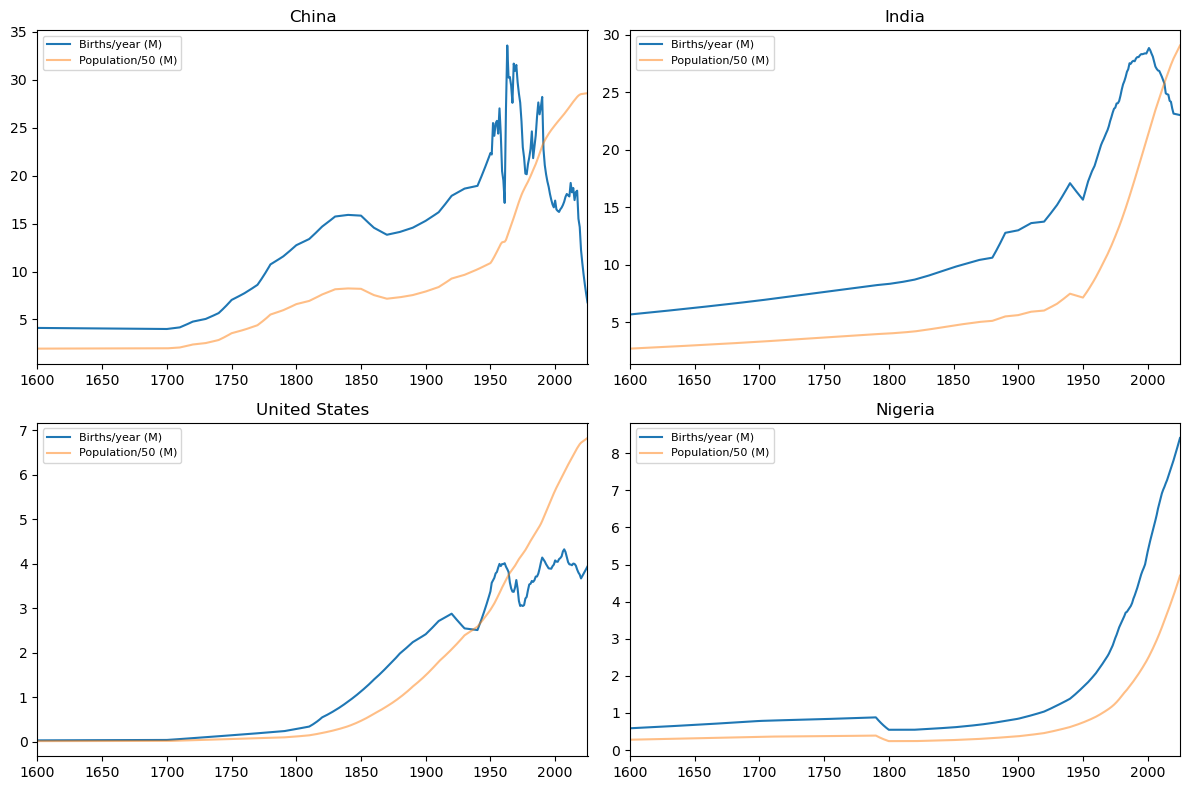

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, country in zip(axes.flat, ['China', 'India', 'United States', 'Nigeria']):
    cd = COUNTRY_DATA[country]
    years = np.arange(1600, 2026)
    births = cd.birth_f(years)
    pop = cd.pop_f(years)
    
    ax.plot(years, births / 1e6, label='Births/year (M)')
    ax.plot(years, pop / 1e6 / 50, label='Population/50 (M)', alpha=0.5)
    ax.set_title(country)
    ax.legend(fontsize=8)
    ax.set_xlim(1600, 2025)

plt.tight_layout()
plt.show()

## Modern countries: total births 1600–2025

Baseline ranking using modern borders over the full dataset span.
Not historically meaningful as a polity ranking, but useful context.

In [4]:
modern_results = []
for country in sorted(COUNTRY_DATA.keys()):
    births = sum_births(country, 1600, 2025)
    py = sum_person_years(country, 1600, 2025)
    modern_results.append({'name': country, 'births': births, 'person_years': py})

df_modern = pd.DataFrame(modern_results).sort_values('births', ascending=False).reset_index(drop=True)
df_modern.index += 1
df_modern['births_M'] = df_modern['births'] / 1e6
df_modern['person_years_M'] = df_modern['person_years'] / 1e6

df_modern[['name', 'births_M', 'person_years_M']].head(30).style.format(
    {'births_M': '{:,.0f}', 'person_years_M': '{:,.0f}'}
).set_caption('Total births and person-years by modern country borders, 1600–2025 (millions)')

,name,births_M,person_years_M
1,China,"5,114","169,335"
2,India,"4,936","137,632"
3,Russia,655,"21,484"
4,Indonesia,627,"19,924"
5,Nigeria,604,"13,965"
6,Pakistan,566,"14,463"
7,United States,560,"27,415"
8,Bangladesh,554,"14,671"
9,Japan,485,"20,106"
10,Germany,384,"15,651"


## Polity definitions

Each polity is a list of `(country, start_year, end_year)` tuples where every listed
modern country is **entirely** within the polity, and the polity doesn't extend significantly
beyond them. Only clean mappings are included here — everything else needs sampling.

In [5]:
POLITIES = {}

# =============================================================
# East Asia
# =============================================================

POLITIES["People's Republic of China (1949–2025)"] = {
    'countries': [('China', 1949, 2025), ('Hong Kong', 1997, 2025)],
    'notes': 'HK returned 1997.',
}

POLITIES['Qing Dynasty (1759–1912)'] = {
    'countries': [
        ('China', 1759, 1912), ('Taiwan', 1759, 1895),
        ('Mongolia', 1759, 1911), ('Hong Kong', 1759, 1842),
    ],
    'notes': 'From maximum extent (Xinjiang 1759) to fall. Taiwan lost 1895, Mongolia independent 1911.',
}

POLITIES['Tokugawa Japan (1603–1868)'] = {
    'countries': [('Japan', 1603, 1868)],
    'notes': 'Island nation, borders unchanged.',
}

POLITIES['Japanese Empire (1868–1945)'] = {
    'countries': [
        ('Japan', 1868, 1945), ('South Korea', 1910, 1945),
        ('North Korea', 1910, 1945), ('Taiwan', 1895, 1945),
    ],
    'notes': 'Korea 1910, Taiwan 1895. Excludes Manchukuo.',
}

POLITIES['Japan (1945–2025)'] = {
    'countries': [('Japan', 1945, 2025)],
}

POLITIES['Joseon Korea (1600–1897)'] = {
    'countries': [('South Korea', 1600, 1897), ('North Korea', 1600, 1897)],
    'notes': 'Data starts 1600; Joseon founded 1392.',
}

POLITIES['South Korea (1948–2025)'] = {'countries': [('South Korea', 1948, 2025)]}
POLITIES['North Korea (1948–2025)'] = {'countries': [('North Korea', 1948, 2025)]}

# =============================================================
# South Asia
# =============================================================

POLITIES['British India (1858–1947)'] = {
    'countries': [
        ('India', 1858, 1947), ('Pakistan', 1858, 1947),
        ('Bangladesh', 1858, 1947), ('Myanmar', 1886, 1948),
    ],
    'notes': 'Pop data includes princely states. Burma from 1886.',
}

POLITIES['India (1947–2025)'] = {'countries': [('India', 1947, 2025)]}

POLITIES['Pakistan (1947–2025)'] = {
    'countries': [('Pakistan', 1947, 2025), ('Bangladesh', 1947, 1971)],
    'notes': 'Included East Pakistan (Bangladesh) until 1971.',
}

POLITIES['Bangladesh (1971–2025)'] = {'countries': [('Bangladesh', 1971, 2025)]}

POLITIES['Nepal (1816–2025)'] = {
    'countries': [('Nepal', 1816, 2025)],
    'notes': 'Post Anglo-Nepalese War. Borders stable since.',
}

POLITIES['Myanmar (1948–2025)'] = {
    'countries': [('Myanmar', 1948, 2025)],
}

# =============================================================
# Russia / USSR
# =============================================================

POLITIES['Soviet Union (1922–1991)'] = {
    'countries': [
        ('Russia', 1922, 1991), ('Ukraine', 1922, 1991),
        ('Belarus', 1922, 1991), ('Uzbekistan', 1922, 1991),
        ('Kazakhstan', 1922, 1991), ('Georgia', 1922, 1991),
        ('Azerbaijan', 1922, 1991), ('Lithuania', 1940, 1990),
        ('Moldova', 1940, 1991), ('Latvia', 1940, 1991),
        ('Kyrgyzstan', 1922, 1991), ('Tajikistan', 1922, 1991),
        ('Armenia', 1922, 1991), ('Turkmenistan', 1922, 1991),
        ('Estonia', 1940, 1991),
    ],
    'notes': 'Baltic states from 1940.',
}

POLITIES['Russia (1991–2025)'] = {'countries': [('Russia', 1991, 2025)]}

# =============================================================
# Europe
# =============================================================

POLITIES['United Kingdom (1707–2025)'] = {
    'countries': [('United Kingdom', 1707, 2025), ('Ireland', 1801, 1922)],
    'notes': 'Great Britain from 1707. Ireland joined 1801, left (minus NI) 1922.',
}

POLITIES['France (1870–2025)'] = {
    'countries': [('France', 1870, 2025)],
    'notes': 'Third Republic onward. Alsace-Lorraine was German 1871–1918 (~3% of pop), minor overcount.',
}

POLITIES['Spain (1600–2025)'] = {
    'countries': [('Spain', 1600, 2025)],
    'notes': 'Metropolitan Spain. Borders essentially unchanged.',
}

POLITIES['Italy (1861–2025)'] = {
    'countries': [('Italy', 1861, 2025)],
    'notes': 'From unification. Lost Istria post-WWII (small).',
}

POLITIES['Nazi Reich (1938–1945)'] = {
    'countries': [('Germany', 1938, 1945), ('Austria', 1938, 1945), ('Czechia', 1939, 1945)],
    'notes': 'Formally incorporated territories only.',
}

POLITIES['Germany (1990–2025)'] = {'countries': [('Germany', 1990, 2025)]}

POLITIES['Poland (1945–2025)'] = {
    'countries': [('Poland', 1945, 2025)],
    'notes': 'Post-WWII borders (shifted west).',
}

POLITIES['Ukraine (1991–2025)'] = {'countries': [('Ukraine', 1991, 2025)]}

# =============================================================
# Middle East
# =============================================================

POLITIES['Turkey (1923–2025)'] = {'countries': [('Turkey', 1923, 2025)]}

POLITIES['Iran (1857–2025)'] = {
    'countries': [('Iran', 1857, 2025)],
    'notes': 'After Treaty of Paris (1857). Modern borders roughly settled.',
}

POLITIES['Egypt (1952–2025)'] = {'countries': [('Egypt', 1952, 2025)]}

POLITIES['Iraq (1932–2025)'] = {
    'countries': [('Iraq', 1932, 2025)],
    'notes': 'From independence.',
}

POLITIES['Saudi Arabia (1932–2025)'] = {
    'countries': [('Saudi Arabia', 1932, 2025)],
    'notes': 'Kingdom unified 1932.',
}

POLITIES['Afghanistan (1893–2025)'] = {
    'countries': [('Afghanistan', 1893, 2025)],
    'notes': 'Durand Line (1893) roughly defines modern border.',
}

POLITIES['Yemen (1990–2025)'] = {
    'countries': [('Yemen', 1990, 2025)],
    'notes': 'North + South unified 1990.',
}

POLITIES['Morocco (1956–2025)'] = {'countries': [('Morocco', 1956, 2025)]}
POLITIES['Algeria (1962–2025)'] = {'countries': [('Algeria', 1962, 2025)]}

POLITIES['Sudan (1956–2011)'] = {
    'countries': [('Sudan', 1956, 2011), ('South Sudan', 1956, 2011)],
    'notes': 'Before South Sudan split.',
}

# =============================================================
# Americas
# =============================================================

POLITIES['United States (1850–2025)'] = {
    'countries': [('United States', 1850, 2025)],
    'notes': 'After Mexican Cession.',
}

POLITIES['Brazil (1822–2025)'] = {
    'countries': [('Brazil', 1822, 2025)],
    'notes': 'Borders stable since independence.',
}

POLITIES['Mexico (1848–2025)'] = {
    'countries': [('Mexico', 1848, 2025)],
    'notes': 'After territory ceded to US.',
}

POLITIES['Colombia (1903–2025)'] = {
    'countries': [('Colombia', 1903, 2025)],
    'notes': 'After Panama secession.',
}

POLITIES['Argentina (1880–2025)'] = {
    'countries': [('Argentina', 1880, 2025)],
    'notes': 'After Conquest of the Desert.',
}

POLITIES['Peru (1824–2025)'] = {'countries': [('Peru', 1824, 2025)]}
POLITIES['Venezuela (1830–2025)'] = {'countries': [('Venezuela', 1830, 2025)]}
POLITIES['Canada (1867–2025)'] = {'countries': [('Canada', 1867, 2025)]}

# =============================================================
# Africa
# =============================================================

POLITIES['Nigeria (1960–2025)'] = {'countries': [('Nigeria', 1960, 2025)]}

POLITIES['DR Congo (1960–2025)'] = {
    'countries': [('Democratic Republic of Congo', 1960, 2025)],
}

POLITIES['Ethiopia (1993–2025)'] = {
    'countries': [('Ethiopia', 1993, 2025)],
    'notes': 'After Eritrean independence.',
}

POLITIES['Tanzania (1964–2025)'] = {'countries': [('Tanzania', 1964, 2025)]}
POLITIES['South Africa (1910–2025)'] = {'countries': [('South Africa', 1910, 2025)]}
POLITIES['Kenya (1963–2025)'] = {'countries': [('Kenya', 1963, 2025)]}
POLITIES['Uganda (1962–2025)'] = {'countries': [('Uganda', 1962, 2025)]}
POLITIES['Ghana (1957–2025)'] = {'countries': [('Ghana', 1957, 2025)]}
POLITIES['Angola (1975–2025)'] = {'countries': [('Angola', 1975, 2025)]}
POLITIES['Mozambique (1975–2025)'] = {'countries': [('Mozambique', 1975, 2025)]}
POLITIES['Madagascar (1960–2025)'] = {'countries': [('Madagascar', 1960, 2025)]}

# =============================================================
# Southeast Asia
# =============================================================

POLITIES['Indonesia (1945–2025)'] = {'countries': [('Indonesia', 1945, 2025)]}
POLITIES['Philippines (1946–2025)'] = {'countries': [('Philippines', 1946, 2025)]}

POLITIES['Vietnam (1976–2025)'] = {
    'countries': [('Vietnam', 1976, 2025)],
    'notes': 'Post-reunification.',
}

POLITIES['Thailand (1909–2025)'] = {
    'countries': [('Thailand', 1909, 2025)],
    'notes': 'Anglo-Siamese Treaty 1909 settled modern borders.',
}

POLITIES['Malaysia (1963–2025)'] = {'countries': [('Malaysia', 1963, 2025)]}

print(f'{len(POLITIES)} polities defined')

58 polities defined


## Results

In [6]:
results = []
for name, defn in POLITIES.items():
    r = compute_polity(name, defn['countries'], defn.get('notes', ''))
    results.append(r)

df = pd.DataFrame(results).sort_values('births', ascending=False).reset_index(drop=True)
df.index += 1
df['births_M'] = df['births'] / 1e6
df['person_years_M'] = df['person_years'] / 1e6

df[['name', 'births_M', 'person_years_M', 'notes']].style.format(
    {'births_M': '{:,.0f}', 'person_years_M': '{:,.0f}'}
).set_caption('Polities ranked by total births (millions)')

,name,births_M,person_years_M,notes
1,Qing Dynasty (1759–1912),"2,091","54,023","From maximum extent (Xinjiang 1759) to fall. Taiwan lost 1895, Mongolia independent 1911."
2,India (1947–2025),"1,857","65,651",
3,People's Republic of China (1949–2025),"1,624","80,027",HK returned 1997.
4,British India (1858–1947),"1,393","31,074",Pop data includes princely states. Burma from 1886.
5,United States (1850–2025),510,"26,388",After Mexican Cession.
6,Pakistan (1947–2025),384,"10,308",Included East Pakistan (Bangladesh) until 1971.
7,Brazil (1822–2025),353,"12,903",Borders stable since independence.
8,Indonesia (1945–2025),352,"13,343",
9,Soviet Union (1922–1991),351,"14,206",Baltic states from 1940.
10,Nigeria (1960–2025),313,"7,415",


## Cumulative and annual births over time

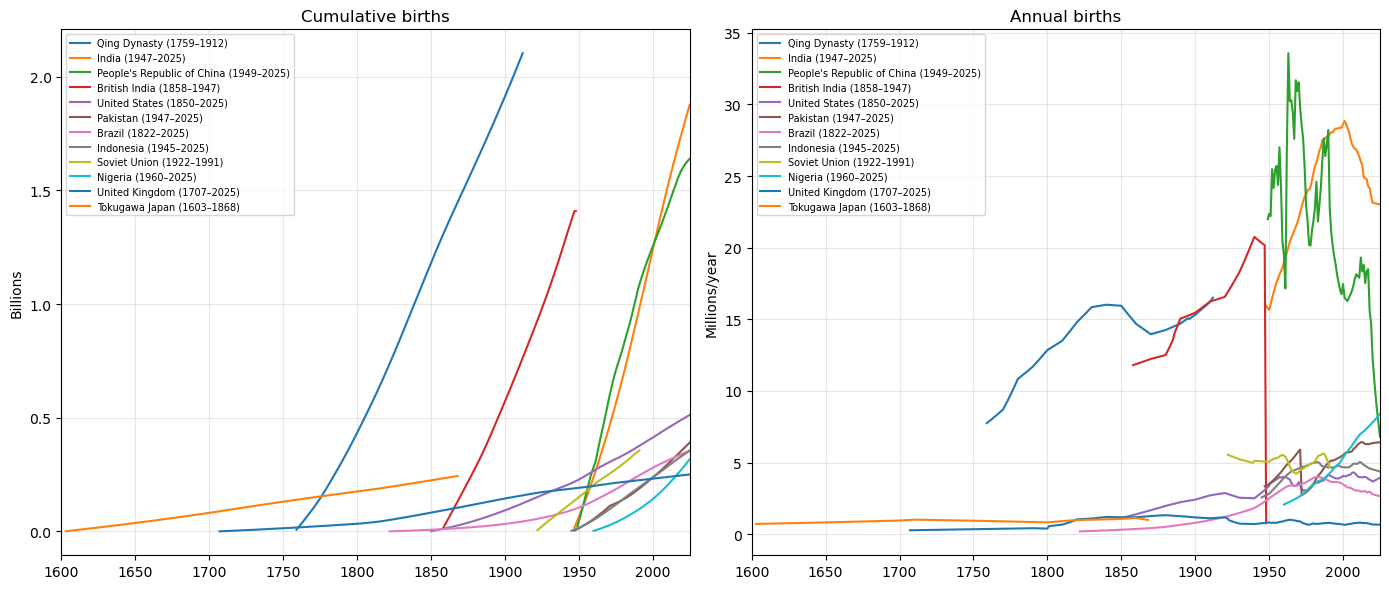

In [7]:
def cumulative_births_series(polity_name):
    """Return (years, cumulative_births, annual_births) for a polity."""
    defn = POLITIES[polity_name]
    min_year = min(max(s, 1600) for _, s, e in defn['countries'])
    max_year = max(min(e, 2025) for _, s, e in defn['countries'])
    years = np.arange(min_year, max_year + 1)
    annual_births = np.zeros_like(years, dtype=float)
    
    for country, start, end in defn['countries']:
        if country not in COUNTRY_DATA:
            continue
        cd = COUNTRY_DATA[country]
        cs = max(start, int(cd.years[0]))
        ce = min(end, int(cd.years[-1]))
        mask = (years >= cs) & (years <= ce)
        if mask.any():
            annual_births[mask] += cd.birth_f(years[mask])
    
    return years, np.cumsum(annual_births), annual_births


# Top polities by births for the plots
top_by_births = df.head(12)['name'].tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for name in top_by_births:
    years, cum, annual = cumulative_births_series(name)
    ax1.plot(years, cum / 1e9, label=name)
    ax2.plot(years, annual / 1e6, label=name)

ax1.set_title('Cumulative births')
ax1.set_ylabel('Billions')
ax1.legend(fontsize=7, loc='upper left')

ax2.set_title('Annual births')
ax2.set_ylabel('Millions/year')
ax2.legend(fontsize=7, loc='upper left')

for ax in (ax1, ax2):
    ax.set_xlim(1600, 2025)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Country-level breakdown within composite polities

In [8]:
def breakdown_polity(polity_name):
    defn = POLITIES[polity_name]
    rows = []
    for country, start, end in defn['countries']:
        if country not in COUNTRY_DATA:
            continue
        b = sum_births(country, start, end)
        py = sum_person_years(country, start, end)
        rows.append({'country': country, 'period': f'{start}–{end}',
                     'births_M': b / 1e6, 'person_years_M': py / 1e6})
    bdf = pd.DataFrame(rows).sort_values('births_M', ascending=False)
    bdf['pct'] = 100 * bdf['births_M'] / bdf['births_M'].sum()
    return bdf

for name in ['Soviet Union (1922–1991)', 'Qing Dynasty (1759–1912)', 'British India (1858–1947)',
             'Japanese Empire (1868–1945)', 'Pakistan (1947–2025)', 'United Kingdom (1707–2025)',
             'Nazi Reich (1938–1945)', 'Sudan (1956–2011)']:
    print(f'\n=== {name} ===')
    bdf = breakdown_polity(name)
    for _, row in bdf.iterrows():
        print(f"  {row['country']:<20} {row['period']:<12} {row['births_M']:>8.1f}M  ({row['pct']:>5.1f}%)")


=== Soviet Union (1922–1991) ===
  Russia               1922–1991       185.7M  ( 52.9%)
  Ukraine              1922–1991        56.7M  ( 16.2%)
  Uzbekistan           1922–1991        25.8M  (  7.4%)
  Kazakhstan           1922–1991        20.4M  (  5.8%)
  Belarus              1922–1991        12.6M  (  3.6%)
  Azerbaijan           1922–1991        10.8M  (  3.1%)
  Tajikistan           1922–1991         7.1M  (  2.0%)
  Georgia              1922–1991         6.8M  (  1.9%)
  Kyrgyzstan           1922–1991         5.9M  (  1.7%)
  Turkmenistan         1922–1991         4.9M  (  1.4%)
  Armenia              1922–1991         4.4M  (  1.2%)
  Moldova              1940–1991         4.0M  (  1.1%)
  Lithuania            1940–1990         2.9M  (  0.8%)
  Latvia               1940–1991         1.8M  (  0.5%)
  Estonia              1940–1991         1.1M  (  0.3%)

=== Qing Dynasty (1759–1912) ===
  China                1759–1912      2075.2M  ( 99.3%)
  Taiwan               1759–1895    

## Person-years ranking

In [9]:
df_py = df.sort_values('person_years', ascending=False).reset_index(drop=True)
df_py.index += 1
df_py[['name', 'person_years_M', 'births_M']].style.format(
    {'person_years_M': '{:,.0f}', 'births_M': '{:,.0f}'}
).set_caption('Polities ranked by person-years (millions)')

,name,person_years_M,births_M
1,People's Republic of China (1949–2025),"80,027","1,624"
2,India (1947–2025),"65,651","1,857"
3,Qing Dynasty (1759–1912),"54,023","2,091"
4,British India (1858–1947),"31,074","1,393"
5,United States (1850–2025),"26,388",510
6,Soviet Union (1922–1991),"14,206",351
7,Indonesia (1945–2025),"13,343",352
8,Brazil (1822–2025),"12,903",353
9,United Kingdom (1707–2025),"10,940",250
10,Pakistan (1947–2025),"10,308",384


## Snapshots: biggest polity at various points in time

In [10]:
def births_at_year(polity_name, year):
    defn = POLITIES[polity_name]
    total = 0
    for country, start, end in defn['countries']:
        if country not in COUNTRY_DATA:
            continue
        if start <= year <= end:
            cd = COUNTRY_DATA[country]
            if cd.years[0] <= year <= cd.years[-1]:
                total += float(cd.birth_f(year))
    return total

snapshot_years = [1700, 1800, 1850, 1900, 1950, 1980, 2000, 2024]

for year in snapshot_years:
    scores = [(name, births_at_year(name, year)) for name in POLITIES]
    scores = [(n, b) for n, b in scores if b > 0]
    scores.sort(key=lambda x: x[1], reverse=True)
    print(f'\n--- {year}: Top polities by births/year (millions) ---')
    for name, val in scores[:8]:
        print(f'  {name:<40} {val/1e6:>8.2f}')


--- 1700: Top polities by births/year (millions) ---
  Tokugawa Japan (1603–1868)                   0.96
  Spain (1600–2025)                            0.31
  Joseon Korea (1600–1897)                     0.26

--- 1800: Top polities by births/year (millions) ---
  Qing Dynasty (1759–1912)                    12.85
  Tokugawa Japan (1603–1868)                   0.83
  Joseon Korea (1600–1897)                     0.58
  Spain (1600–2025)                            0.42
  United Kingdom (1707–2025)                   0.39

--- 1850: Top polities by births/year (millions) ---
  Qing Dynasty (1759–1912)                    15.95
  United Kingdom (1707–2025)                   1.18
  United States (1850–2025)                    1.13
  Tokugawa Japan (1603–1868)                   1.07
  Joseon Korea (1600–1897)                     0.59
  Spain (1600–2025)                            0.54
  Mexico (1848–2025)                           0.36
  Brazil (1822–2025)                           0.31

--- 1

## Classify the 100k sample using polity assignments

Load the 100,000 randomly sampled people and classify each one using our
`assign_polity()` function. This tells us what fraction of all humans ever born
we can assign to a known polity vs. indeterminate vs. no known polities.

In [ ]:
from polity_assignments_data import assign_polity, ASSIGNMENT

# Load the 100k sample
with open('../FamousPerson/famous_person_sample_100000.pkl', 'rb') as f:
    people = dill.load(f)

print(f'Loaded {len(people)} people')

# Classify each person
results = []
for p in people:
    if p.era == 'Paleolithic':
        results.append({
            'birth_year': p.birth_year,
            'country': None,
            'era': 'Paleolithic',
            'polity': 'no_known_polities',
        })
    else:
        country = p.location.country
        polity = assign_polity(country, p.birth_year)
        results.append({
            'birth_year': p.birth_year,
            'country': country,
            'era': 'Holocene',
            'polity': polity,
        })

df_sample = pd.DataFrame(results)

# Summary
total = len(df_sample)
assigned = df_sample[~df_sample['polity'].isin(['indeterminate', 'no_known_polities', None])]
indeterminate = df_sample[df_sample['polity'] == 'indeterminate']
no_polity = df_sample[df_sample['polity'] == 'no_known_polities']

print(f"\nClassification summary:")
print(f"  Assigned to a polity:  {len(assigned):>6} ({100*len(assigned)/total:.1f}%)")
print(f"  Indeterminate:         {len(indeterminate):>6} ({100*len(indeterminate)/total:.1f}%)")
print(f"  No known polities:     {len(no_polity):>6} ({100*len(no_polity)/total:.1f}%)")
print(f"  Total:                 {total:>6}")

In [ ]:
# Top polities by number of sampled people
polity_counts = assigned['polity'].value_counts().head(40)
print("Top 40 polities by sampled births:\n")
print(f"{'Polity':<50} {'Count':>6} {'%':>6}")
print("-" * 65)
for polity, count in polity_counts.items():
    print(f"{polity:<50} {count:>6} {100*count/total:>5.1f}%")

In [ ]:
# Where are the biggest gaps? Which (country, century) pairs have the most indeterminate?
indet = df_sample[df_sample['polity'] == 'indeterminate'].copy()
indet['century'] = (indet['birth_year'] // 100) * 100
gap_analysis = indet.groupby(['country', 'century']).size().sort_values(ascending=False).head(30)
print("Top 30 (country, century) gaps — indeterminate assignments:\n")
print(f"{'Country':<25} {'Century':>8} {'Count':>6}")
print("-" * 42)
for (country, century), count in gap_analysis.items():
    century_str = f"{abs(century)} {'BC' if century < 0 else 'AD'}"
    print(f"{country:<25} {century_str:>8} {count:>6}")